# Train RBM on lattice MSA

In [1]:
import os, sys
pgm_path = '../../PGM/'

sys.path.append(pgm_path + 'source/')
sys.path.append(pgm_path + 'utilities/')

import rbm, RBM_utils
import utilities, Proteins_utils, sequence_logo, plots_utils 

import random
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


e:\ESCAPE_PATHS\lattice\rbm\../../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\lattice\rbm\../../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [ ]:
import os

def create_fasta_for_each_file(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for file_name in os.listdir(input_folder):
        if  file_name.endswith(".txt"):
            input_file_path = os.path.join(input_folder, file_name)
            output_fasta_file = os.path.join(output_folder, f"{os.path.splitext(file_name)[0]}.fasta")
            if os.path.exists(output_fasta_file):
                print(f"FASTA file '{output_fasta_file}' already exists.")
                continue
            with open(output_fasta_file, 'w') as fasta_file:
                with open(input_file_path, 'r') as input_file:
                    for index, line in enumerate(input_file):
                        pnat, beta, sequence = line.split()
                        header = f">seq_{index} pnat:{pnat} beta:{beta}"
                        fasta_file.write(f"{header}\n{sequence}\n")

            print(f"FASTA file '{output_fasta_file}' created successfully.")

create_fasta_for_each_file('../msa', '../msa')


FASTA file '../msa\output_msa_structure_0_beta_10.fasta' already exists.
FASTA file '../msa\output_msa_structure_0_beta_100.fasta' already exists.
FASTA file '../msa\output_msa_structure_0_beta_1000.fasta' already exists.


training on file:  structure_0_beta_10
shape of sequences: (200, 27)
Train sequences shape: (180, 27)
Validation sequences shape: (20, 27)
Random data shape: (180, 27)
Mismatch dimensions (100, 20), [10, 20], reinitializating I
Mismatch dimensions (100, 27, 20), [10, 27, 20], reinitializating I
-52.593304


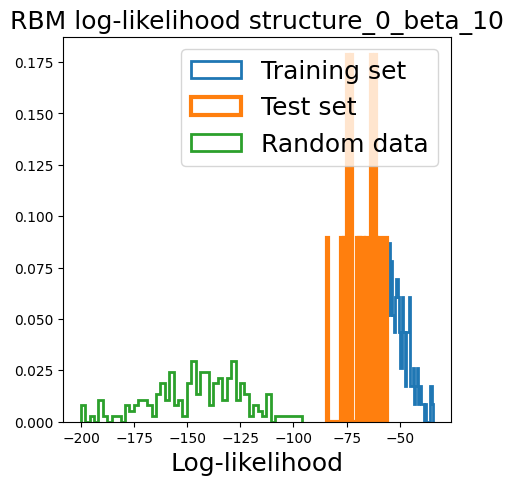

skipped output_msa_structure_0_beta_10.txt
training on file:  structure_0_beta_100
shape of sequences: (200, 27)
Train sequences shape: (180, 27)
Validation sequences shape: (20, 27)
Random data shape: (180, 27)
Mismatch dimensions (100, 20), [10, 20], reinitializating I
Mismatch dimensions (100, 27, 20), [10, 27, 20], reinitializating I
-42.601204


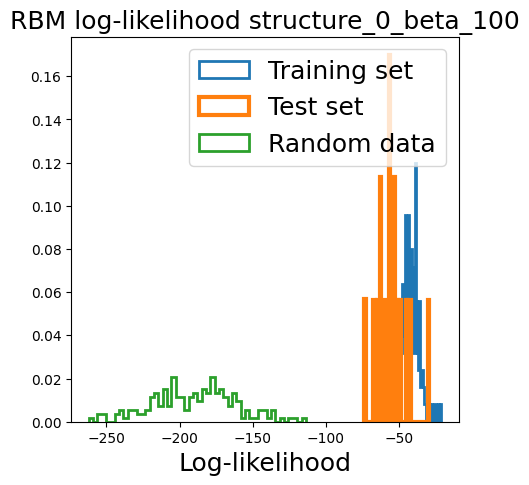

skipped output_msa_structure_0_beta_100.txt
training on file:  structure_0_beta_1000
shape of sequences: (199, 27)
Train sequences shape: (180, 27)
Validation sequences shape: (19, 27)
Random data shape: (180, 27)
Mismatch dimensions (100, 20), [10, 20], reinitializating I
Mismatch dimensions (100, 27, 20), [10, 27, 20], reinitializating I
-27.23658


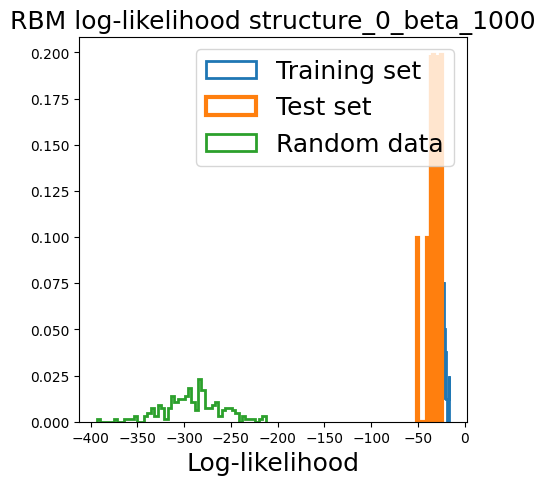

skipped output_msa_structure_0_beta_1000.txt


In [ ]:
files=os.listdir('../msa')
path_data='../msa/'
for file in files:
    if not file.startswith("output") or not file.endswith(".fasta"):
        print('skipped '+file)
        continue
    name=file[11:-6]
    print('training on file: ' ,name)
    
    sequences = Proteins_utils.load_FASTA(path_data+file) 
    print('shape of sequences:', np.shape(sequences))

    sequences=np.array(sequences)

    perm = np.arange(sequences.shape[0])
    np.random.seed(2)
    np.random.shuffle(perm)

    len_validation = sequences.shape[0] // 10
    train_sequences=sequences[perm[:-len_validation]]
    validation_sequences=sequences[perm[-len_validation:]]
    rand_data = np.random.randint(low=0, high=20, size=train_sequences.shape, dtype=np.int16)

    print('Train sequences shape:', train_sequences.shape)
    print('Validation sequences shape:', validation_sequences.shape)
    print('Random data shape:', rand_data.shape)

    np.random.seed(None)

    sequence_weights = np.ones(train_sequences.shape[0])

    RBM = rbm.RBM(
                visible = 'Potts', # Categorical visible data.
                hidden = 'dReLU', # double ReLU hidden units.
                n_v = sequences.shape[-1], # Data dimension (here, number of columns in MSA)
                n_cv = 20, # Number of categories (here, 20 amino acids + 1 gap)
                n_h = 20 # Number of hidden units: 100
                ) 
    RBM.fit(train_sequences, weights = sequence_weights, n_iter=50, N_MC=5,verbose=0, vverbose=0, l1b=0.01) # Fit by Persistent Contrastive Divergence for 500 epochs, 10 Monte Carlo steps; L_1^2 sparse regularization penalty = 0.1.

    RBM_utils.saveRBM('RBM_'+str(name), RBM) 
    print( RBM.likelihood(train_sequences).mean() ) 

    fig = plt.figure(figsize=(5, 5), constrained_layout=False)
    ax = fig.add_subplot()
    ax.hist(RBM.likelihood(train_sequences), bins=50, density=True, histtype='step', lw=2, fill=False, label="Training set")
    ax.hist(RBM.likelihood(validation_sequences), bins=50, density=True, histtype='step', lw=3, fill=False, label="Test set")
    ax.hist(RBM.likelihood(rand_data), bins=50, density=True, histtype='step', lw=2, fill=False, label="Random data")

    ax.legend(fontsize=18, loc=1)
    ax.set_xlabel("Log-likelihood", fontsize=18)

    ax.set_title("RBM log-likelihood "+name, fontsize=18)

    plt.show()